# Feature engineering


1. **Feature ablation:** drop one feature at a time, compare AUC/deadtime
2. **L1 scan:** sweep `reg_alpha`, watch which feature importances collapse
3. **Permutation importance:** model-agnostic measure of feature contribution at inference

In [1]:
import sys
sys.path.append("../../../src/ml")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyutils.pyplot import Plot
Plot(verbosity=0)

run = "k"

## Load data

In [2]:
from assemble import AssembleDataset
asm = AssembleDataset(run=run)
data = asm.assemble_dataset()

all_features = list(data["X_train"].columns)
print(f"Features ({len(all_features)}): {all_features}")

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Loaded data
[Assemble] [OK] Initialised
[Assemble] [OK] Split data 70/15/15 (event-level grouping)
  Train: 1515614 coincidences
  Val:   324341 coincidences
  Test:  323573 coincidences
Features (9): ['crv_x', 'crv_y', 'crv_z', 'PEs', 'dT', 'nHits', 'nLayers', 'angle', 'sector']


In [3]:
# Baseline hyperparameters from optimisation
best_hp = {
    "n_estimators": 200,
    "max_depth": 7,
    "learning_rate": 0.1,
    "tree_method": "hist",
    "device": "cuda",
}

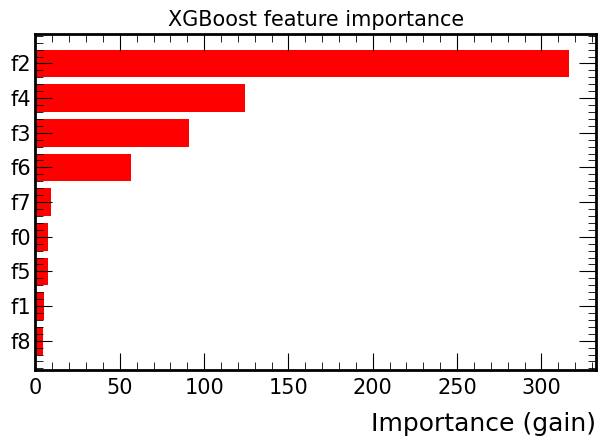

In [18]:
# XGBoost feature importance
importances = results["model"].get_booster().get_score(importance_type="gain")
imp_df = pd.DataFrame({
    "feature": importances.keys(),
    "importance": importances.values(),
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.barh(imp_df["feature"], imp_df["importance"])
ax.set_xlabel("Importance (gain)")
ax.set_title("XGBoost feature importance")
plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/xgb_importance.png")
plt.show()


## 1. Feature ablation

Drop one feature at a time and compare performance with the baseline (all features).

In [4]:
from train import Train
from validate import Validate

def train_with_features(data, features, tag, best_hp):
    """Train and validate with a subset of features."""
    subset = {
        "X_train": data["X_train"][features],
        "X_test": data["X_test"][features],
        "X_val": data["X_val"][features],
        "y_train": data["y_train"],
        "y_test": data["y_test"],
        "y_val": data["y_val"],
        "metadata_train": data["metadata_train"],
        "metadata_test": data["metadata_test"],
        "metadata_val": data["metadata_val"],
    }
    trn = Train(subset, run=run, verbosity=0)
    results = trn.train(tag=tag, save_output=False, **best_hp)
    val = Validate(results, run=run, verbosity=0)
    val.roc_auc()
    thr = val.find_threshold(min_eff=0.999, plot=False, show=False)
    return {
        "train_auc": val._train_auc,
        "test_auc": val._test_auc,
        "overfit_gap": val._train_auc - val._test_auc,
        "threshold": thr["threshold"],
        "veto_efficiency": thr["veto_efficiency"],
        "deadtime": thr["deadtime"],
    }

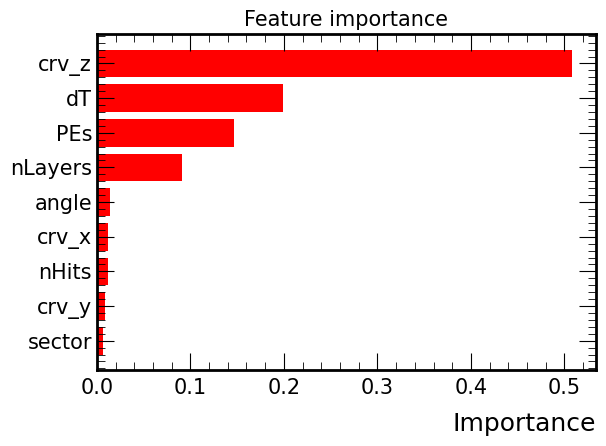

In [21]:
# XGBoost feature importance (gain)
# importances = results["model"].get_booster().get_score(importance_type="gain")
importances = dict(zip(all_features, results["model"].feature_importances_))
imp_df = pd.DataFrame({
    "feature": importances.keys(),
    "importance": importances.values(),
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.barh(imp_df["feature"], imp_df["importance"])
ax.set_xlabel("Importance")
ax.set_title("Feature importance")
plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/xgb_importance.png")
plt.show()


In [5]:
# Baseline: all features
baseline = train_with_features(data, all_features, "baseline", best_hp)
print(f"Baseline ({len(all_features)} features): test AUC={baseline['test_auc']:.6f}, deadtime={baseline['deadtime']*100:.3f}%")

# Drop one feature at a time
ablation_results = []
for feat in all_features:
    reduced = [f for f in all_features if f != feat]
    result = train_with_features(data, reduced, f"drop_{feat}", best_hp)
    result["dropped"] = feat
    result["n_features"] = len(reduced)
    ablation_results.append(result)
    delta_auc = result["test_auc"] - baseline["test_auc"]
    print(f"  Drop {feat:>10s}: test AUC={result['test_auc']:.6f} (delta={delta_auc:+.6f}), deadtime={result['deadtime']*100:.3f}%")

ablation_df = pd.DataFrame(ablation_results).sort_values("test_auc", ascending=False)
display(ablation_df)

Baseline (9 features): test AUC=0.999912, deadtime=2.655%
  Drop      crv_x: test AUC=0.999904 (delta=-0.000009), deadtime=4.351%
  Drop      crv_y: test AUC=0.999929 (delta=+0.000016), deadtime=3.427%
  Drop      crv_z: test AUC=0.999932 (delta=+0.000020), deadtime=0.704%
  Drop        PEs: test AUC=0.999828 (delta=-0.000085), deadtime=3.007%
  Drop         dT: test AUC=0.999747 (delta=-0.000165), deadtime=7.314%
  Drop      nHits: test AUC=0.999902 (delta=-0.000011), deadtime=0.242%
  Drop    nLayers: test AUC=0.999907 (delta=-0.000005), deadtime=1.422%
  Drop      angle: test AUC=0.999927 (delta=+0.000015), deadtime=1.360%
  Drop     sector: test AUC=0.999933 (delta=+0.000021), deadtime=1.542%


,train_auc,test_auc,overfit_gap,threshold,veto_efficiency,deadtime,dropped,n_features
8,0.999982,0.999933,0.000049,0.000900,0.999348,0.015421,sector,8
2,0.999977,0.999932,0.000045,0.007101,0.999022,0.007036,crv_z,8
1,0.999982,0.999929,0.000053,0.000300,0.999022,0.034267,crv_y,8
7,0.999981,0.999927,0.000054,0.001400,0.999022,0.013598,angle,8
6,0.999982,0.999907,0.000075,0.001100,0.999022,0.014221,nLayers,8
0,0.999983,0.999904,0.000079,0.000200,0.999348,0.043506,crv_x,8
5,0.999980,0.999902,0.000078,0.029903,0.999022,0.002422,nHits,8
3,0.999968,0.999828,0.000140,0.001500,0.999022,0.030069,PEs,8
4,0.999947,0.999747,0.000200,0.000400,0.999022,0.073136,dT,8


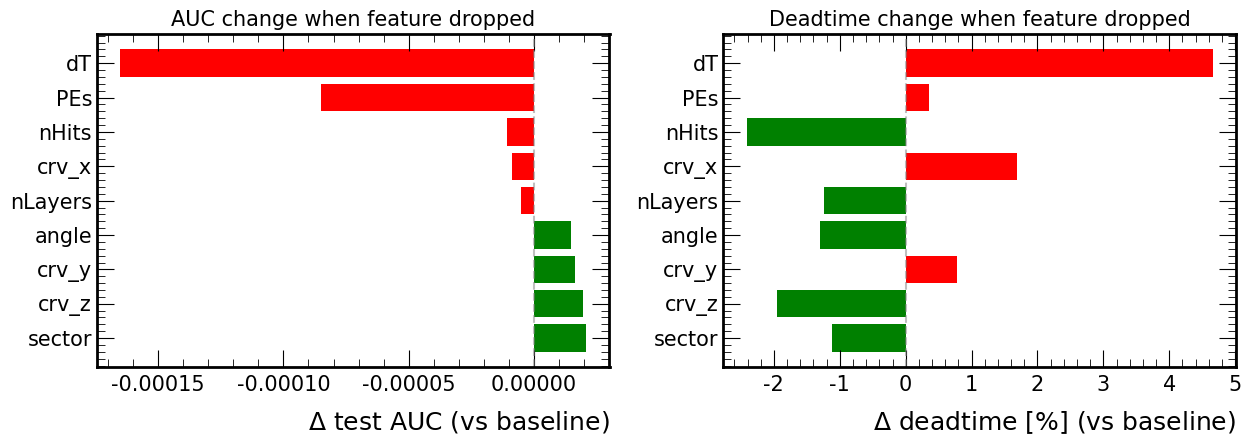

In [12]:
# Plot ablation results
fig, axes = plt.subplots(1, 2, figsize=(2*6.4, 4.8))

features_sorted = ablation_df["dropped"].values
delta_auc = ablation_df["test_auc"].values - baseline["test_auc"]
delta_deadtime = (ablation_df["deadtime"].values - baseline["deadtime"]) * 100

ax = axes[0]
colours = ["green" if d >= 0 else "red" for d in delta_auc]
ax.barh(features_sorted, delta_auc, color=colours)
ax.axvline(0, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("$\Delta$ test AUC (vs baseline)")
ax.set_title("AUC change when feature dropped")

ax = axes[1]
colours = ["green" if d <= 0 else "red" for d in delta_deadtime]
ax.barh(features_sorted, delta_deadtime, color=colours)
ax.axvline(0, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("$\Delta$ deadtime [%] (vs baseline)")
ax.set_title("Deadtime change when feature dropped")

plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/ablation.png")
plt.show()

In [10]:
# !mkdir ../../../output/images/ml/k/features/

## 2. L1 regularisation scan

Sweep `reg_alpha` and track feature importances. Features whose importance drops to ~0 at moderate L1 are candidates for removal.

In [13]:
import xgboost as xgb

alphas = [0, 0.1, 1, 5, 10, 50, 100]
importance_records = []

for alpha in alphas:
    hp = {**best_hp, "reg_alpha": alpha}
    trn = Train(data, run=run, verbosity=0)
    results = trn.train(tag=f"l1_alpha_{alpha}", save_output=False, **hp)

    # XGBoost feature importance (gain)
    importances = results["model"].get_booster().get_score(importance_type="gain")
    for feat in all_features:
        importance_records.append({
            "reg_alpha": alpha,
            "feature": feat,
            "importance": importances.get(feat, 0.0),
        })

    val = Validate(results, run=run, verbosity=0)
    val.roc_auc()
    print(f"  reg_alpha={alpha:>5}: test AUC={val._test_auc:.6f}")

l1_df = pd.DataFrame(importance_records)

  reg_alpha=    0: test AUC=0.999912
  reg_alpha=  0.1: test AUC=0.999936
  reg_alpha=    1: test AUC=0.999931
  reg_alpha=    5: test AUC=0.999917
  reg_alpha=   10: test AUC=0.999898
  reg_alpha=   50: test AUC=0.999429
  reg_alpha=  100: test AUC=0.999366


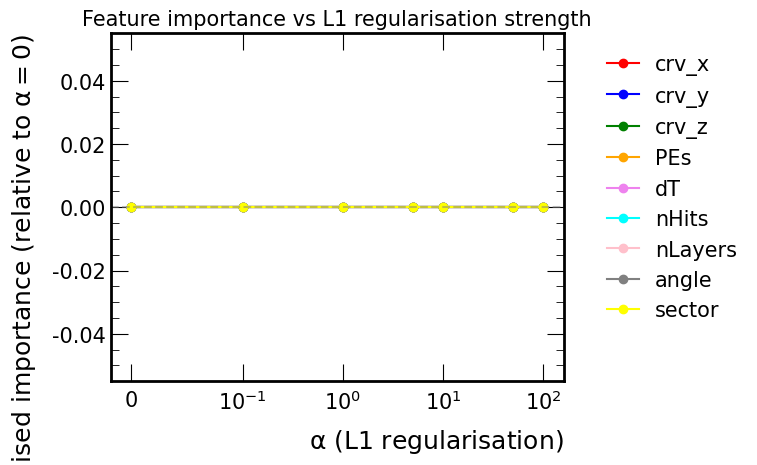

In [14]:
# Plot feature importance vs L1 strength
fig, ax = plt.subplots(figsize=(8, 5))

for feat in all_features:
    feat_data = l1_df[l1_df["feature"] == feat]
    # Normalise importance relative to alpha=0 value
    base_imp = feat_data[feat_data["reg_alpha"] == 0]["importance"].values[0]
    if base_imp > 0:
        norm_imp = feat_data["importance"].values / base_imp
    else:
        norm_imp = feat_data["importance"].values
    ax.plot(feat_data["reg_alpha"], norm_imp, marker="o", label=feat)

ax.set_xlabel(r"$\alpha$ (L1 regularisation)")
ax.set_xscale("symlog", linthresh=0.1)
ax.set_ylabel("Normalised importance (relative to $\\alpha=0$)")
ax.set_title("Feature importance vs L1 regularisation strength")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.axhline(0, color="grey", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/l1_importance.png")
plt.show()

## 3. Permutation importance

Measures actual impact of each feature on test set predictions by shuffling one feature at a time. Model-agnostic and accounts for feature interactions.

In [15]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

# Train baseline model
trn = Train(data, run=run, verbosity=0)
results = trn.train(tag="perm_baseline", save_output=False, **best_hp)

# Permutation importance on test set
perm_result = permutation_importance(
    results["model"],
    data["X_test"], data["y_test"],
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
)

perm_df = pd.DataFrame({
    "feature": all_features,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=True)

display(perm_df.sort_values("importance_mean", ascending=False))

,feature,importance_mean,importance_std
3,PEs,0.036150,0.000522
4,dT,0.022734,0.000509
2,crv_z,0.004444,0.000209
5,nHits,0.003455,0.000069
7,angle,0.000180,0.000037
0,crv_x,0.000071,0.000018
1,crv_y,0.000052,0.000012
6,nLayers,0.000038,0.000006
8,sector,-0.000012,0.000009


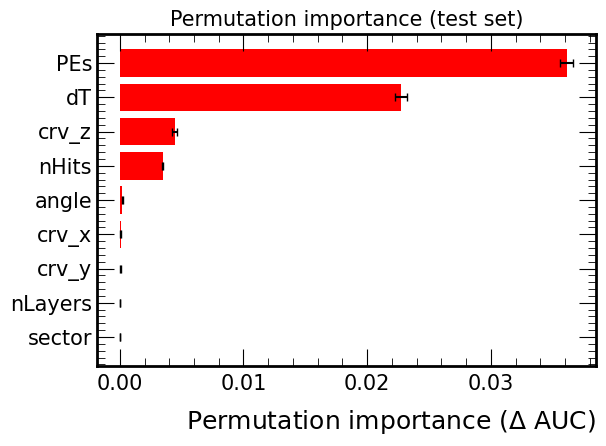

In [16]:
# Plot permutation importance
fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.barh(perm_df["feature"], perm_df["importance_mean"],
        xerr=perm_df["importance_std"], capsize=3)
ax.set_xlabel("Permutation importance ($\Delta$ AUC)")
ax.set_title("Permutation importance (test set)")

plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/permutation_importance.png")
plt.show()

## 4. Summary

Compare all three methods to identify features that are consistently unimportant.

In [17]:
# Combine results from all three methods
summary = pd.DataFrame({"feature": all_features})

# Ablation: AUC change when dropped (negative = feature is useful)
ablation_map = ablation_df.set_index("dropped")
summary["ablation_delta_auc"] = summary["feature"].map(
    lambda f: ablation_map.loc[f, "test_auc"] - baseline["test_auc"]
)

# L1: normalised importance at reg_alpha=10 (features that survive strong L1 are important)
l1_alpha10 = l1_df[l1_df["reg_alpha"] == 10].set_index("feature")
l1_alpha0 = l1_df[l1_df["reg_alpha"] == 0].set_index("feature")
summary["l1_retained"] = summary["feature"].map(
    lambda f: l1_alpha10.loc[f, "importance"] / l1_alpha0.loc[f, "importance"]
    if l1_alpha0.loc[f, "importance"] > 0 else 0
)

# Permutation importance
perm_map = perm_df.set_index("feature")
summary["perm_importance"] = summary["feature"].map(
    lambda f: perm_map.loc[f, "importance_mean"]
)

summary = summary.sort_values("perm_importance", ascending=False)
display(summary)

,feature,ablation_delta_auc,l1_retained,perm_importance
3,PEs,-0.000085,0,0.036150
4,dT,-0.000165,0,0.022734
2,crv_z,0.000020,0,0.004444
5,nHits,-0.000011,0,0.003455
7,angle,0.000015,0,0.000180
0,crv_x,-0.000009,0,0.000071
1,crv_y,0.000016,0,0.000052
6,nLayers,-0.000005,0,0.000038
8,sector,0.000021,0,-0.000012


L1 retained is zero for everything, confirms it's not useful here. Ignore it.

The ablation and permutation importance tell a consistent narrative:

- PEs and dT are clearly the most important features
- crv_z and nHits contribute modestly
- angle, crv_x, crv_y, nLayers — negligible impact. Dropping them barely changes AUC.
- sector permutation importance is negative, meaning shuffling it slightly improves performance. It's noise.

Could likely run with just PEs, dT, crv_z, nHits (4 features) and get essentially the same performance. 

In [22]:
reduced_features = ["PEs", "dT", "crv_z", "nHits"]
reduced = train_with_features(data, reduced_features, "reduced_4", best_hp)
print(f"4 features: test AUC={reduced['test_auc']:.6f}, deadtime={reduced['deadtime']*100:.3f}%")
print(f"Baseline:   test AUC={baseline['test_auc']:.6f}, deadtime={baseline['deadtime']*100:.3f}%")

4 features: test AUC=0.999860, deadtime=6.467%
Baseline:   test AUC=0.999912, deadtime=2.655%


In [23]:
base = ["PEs", "dT", "crv_z", "nHits"]
candidates = ["angle", "crv_x", "crv_y", "nLayers", "sector"]

for feat in candidates:
    test_features = base + [feat]
    result = train_with_features(data, test_features, f"base4_plus_{feat}", best_hp)
    print(f"+{feat:>10s}: test AUC={result['test_auc']:.6f}, deadtime={result['deadtime']*100:.3f}%")


+     angle: test AUC=0.999885, deadtime=3.935%
+     crv_x: test AUC=0.999917, deadtime=1.323%
+     crv_y: test AUC=0.999909, deadtime=3.584%
+   nLayers: test AUC=0.999911, deadtime=5.867%
+    sector: test AUC=0.999873, deadtime=4.645%


In [24]:
five = ["PEs", "dT", "crv_z", "nHits", "crv_x"]
result = train_with_features(data, five, "reduced_5", best_hp)
print(f"5 features: test AUC={result['test_auc']:.6f}, deadtime={result['deadtime']*100:.3f}%")


5 features: test AUC=0.999917, deadtime=1.323%


In [25]:
base5 = ["PEs", "dT", "crv_z", "nHits", "crv_x"]
candidates = ["angle", "crv_y", "nLayers", "sector"]

for feat in candidates:
    test_features = base5 + [feat]
    result = train_with_features(data, test_features, f"base5_plus_{feat}", best_hp)
    print(f"+{feat:>10s}: test AUC={result['test_auc']:.6f}, deadtime={result['deadtime']*100:.3f}%")


+     angle: test AUC=0.999922, deadtime=2.967%
+     crv_y: test AUC=0.999925, deadtime=2.521%
+   nLayers: test AUC=0.999922, deadtime=0.900%
+    sector: test AUC=0.999918, deadtime=1.114%


In [26]:
six = ["PEs", "dT", "crv_z", "nHits", "crv_x", "nLayers"]
result = train_with_features(data, six, "reduced_6", best_hp)
print(f"6 features: test AUC={result['test_auc']:.6f}, deadtime={result['deadtime']*100:.3f}%")


6 features: test AUC=0.999922, deadtime=0.900%


In [27]:
base6 = ["PEs", "dT", "crv_z", "nHits", "crv_x", "nLayers"]
candidates = ["angle", "crv_y", "sector"]

for feat in candidates:
    test_features = base6 + [feat]
    result = train_with_features(data, test_features, f"base6_plus_{feat}", best_hp)
    print(f"+{feat:>10s}: test AUC={result['test_auc']:.6f}, deadtime={result['deadtime']*100:.3f}%")


+     angle: test AUC=0.999909, deadtime=1.260%
+     crv_y: test AUC=0.999921, deadtime=1.009%
+    sector: test AUC=0.999925, deadtime=0.902%
